# C.4 找得到也選得中嗎？


2+2的候選是3、3、4。正解已經在集合，多數決仍會選3。要分開問「有沒有找到」與「怎樣交出正解」，否則更多候選也可能只讓同一錯解得更多票。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

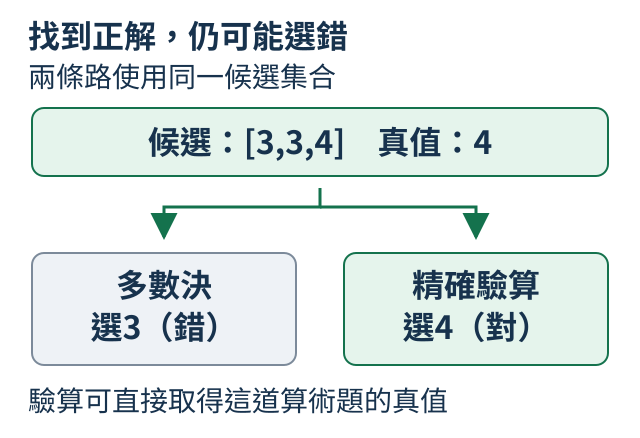

In [2]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/rewrite-C-candidate-choice.svg")))

In [3]:
from collections import Counter

candidates = [3, 3, 4]
majority = Counter(candidates).most_common(1)[0][0]
verified = next((x for x in candidates if x == 2 + 2), None)
print("集合包含正解", 4 in candidates)
print("多數決", majority, "答對", majority == 4)
print("驗證器", verified, "答對", verified == 4)

集合包含正解 True
多數決 3 答對 False
驗證器 4 答對 True


集合含正解True；Counter數兩票3、一票4，選3、False。另一條用2+2驗算，next取第一個通過的4、True；全部不通過時None，沒有從空的正解集合補一個答案。

多數決看出現次數，不懂等式。驗算路線則有可直接計算的真值，是這個窄任務的強條件，不假定未知事實也有這樣的驗證器。開放書店地址不能靠預埋青街8號來證明一般選擇能力。

舊短答題 `(3+3)+0` 曾抽到 `[5,7,5,6]`，集合有6卻投票選5。這個對照用同一批候選，沒有把不同採樣混比。可以分別記完整題目最終正確率，以及「確有正解的集合」裏選對比例；後者分母更小，不能都叫同一個成功率。

<details>
<summary>補充：平票、成功率分母與驗證器的限制</summary>

舊實驗的多數決取最多次的可解析最後整數，平票則取先出現者，不要求超過一半票數。例如候選數k=2的步驟題`(5+0)+3=?`先生成10，再生成8，平票取10而錯；精確驗證器檢查等式後選8。這裡的k就是每題候選份數。

候選數k=8時，24題中有14題的集合至少含一份正解，多數決在其中選對12題。因此「找到之後選對」是12/14，全體題目的最終正確則是12/24。兩個分母衡量不同步驟；集合是否含正解的定義見[C.3](https://birdhackor.github.io/tiny-perceptron-vlm/C.3.html)。

精確驗證器能直接計算這個窄任務的真值，並選第一份全部檢查通過的候選。候選覆蓋率只檢查集合是否有最後答案正確的候選；中間等式錯、最後答案對的候選仍可計入覆蓋率，卻不會被驗證器接受。本次短答與步驟題的八組紀錄中，含正解的集合也都含一份全部檢查通過的候選，因此驗證器的選擇正確率恰好等於候選覆蓋率（oracle coverage）。這個強條件不能延伸到未知事實與開放論證。多份候選同意，或可見等式都正確，也不足以證明可見推理文字反映了模型的實際內部運算，也就是推理步驟的忠實性。完整候選記錄見[實驗報告](https://github.com/birdhackor/tiny-perceptron-vlm/blob/main/docs/course-experiments/results/reasoning.json)。

</details>
